## Jogos Olímpicos e Paralímpicos de Verão: Análise Comparativa e Socioeconômica do Desempenho Global

### Integrantes:
- Élia Dutra Sena
- Luis Fernando de Araujo Oliveira
- Maria Eloisa Silva de Sousa
- Maria Clara Caldas Fernandes

--- 

### Introdução:

// Motivação e objetivos da análise

### Dados Usados:

## Base de Dados:
- Dados esportivos:
  
  Histórico de medalhas por ano: país e suas respectivas medalhas recebidas da olimpíada do ano.
  
  Histórico de medalhas geral: país e a quantidade total de medalhas adquiridas em todas as olimpíadas.
  
  Atletas (Kaggle): dados gerais (nome, gênero, idade, peso, altura, time, esporte, cidade, medalha) sobre todos os atletas que participaram das olimpíadas entre 1896-2016.

  
- Dados socioeconômicos:
  
  PIB mundial.
  
  IDH mundial.


  se usar os sem medlhas colocar

### Pré-processamento: 

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler   
import scipy.stats as stats

##### Tratamento do CSV dos atletas:

Cria um dataframe que lê o arquivo com os dados dos atletas:

In [16]:
df = pd.read_csv('athlete_events.csv', encoding='ISO-8859-1')
display(df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Organiza o arquivo tirando as linhas que tem atletas que competiram  em edições anteriores a de 1960 e nas olimpíadas de inverno e cria um novo CSV com os dados arrumados:

In [17]:
df_organizado = df[df['Year'] >= 1960].copy()
df_organizado = df_organizado[df_organizado["Season"] != "Winter"]

df_organizado.to_csv('athlete_events_limpo.csv', index=False, encoding='ISO-8859-1')
df_organizado.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN


##### Tratamento dos arquivos de medalhas das Paralimpíadas e Olimpíadas :

**Olimpíadas:**

Trata o nome dos países, pois estava diferente do que tem no PIB e dava erro ao tentar juntar os datasets.

    Como era: Brasil (BRA)
    Após o tratamento: fica uma coluna para o país que tem apenas o nome: Brasil e cria uma nova coluna que recebe o NOC: BRA.

Organizamos a posição dos países para que os que mais têm medalhas fiquem no topo.

Após tratar, cria um novo CSV.

In [28]:
df_olimpiadas = pd.read_csv('medalhas_olimpiadas_wikipedia.csv', encoding='utf-8')
display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
2,3,CHN China,12,302,227,197,726
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818


In [ ]:
df_olimpiadas = df_olimpiadas.sort_values(by='Total', ascending=False)
display(df_olimpiadas.head())


,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818
2,3,CHN China,12,302,227,197,726
...,...,...,...,...,...,...,...
150,147,ERI Eritreia,6,0,0,1,1
151,147,GUY Guiana,18,0,0,1,1
152,147,IRQ Iraque,15,0,0,1,1
153,147,MRI Maurício,10,0,0,1,1


In [ ]:
df_olimpiadas_limpo = df_olimpiadas['País'].str.extract(r'^([A-Z]{3})\s+(.*)')
df_olimpiadas_limpo.columns = ['NOC', 'País_Limpo']

df_olimpiadas['NOC'] = df_olimpiadas_limpo['NOC']
df_olimpiadas['País'] = df_olimpiadas_limpo['País_Limpo']

df_olimpiadas['País'] = df_olimpiadas['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA
2,3,China,12,302,227,197,726,CHN


In [31]:
df_olimpiadas.to_csv('olimpiadas_medalhas_arrumado.csv', index=False, encoding='utf-8')

**Paralimpíadas:**

Trata o nome dos países, pois estava diferente do que tem no PIB e dava erro ao tentar juntar os datasets.

    Como era: Brasil (BRA)
    Após o tratamento: fica uma coluna para o país que tem apenas o nome: Brasil e cria uma nova coluna que recebe o NOC: BRA.

Além disso, Unifica as Alemanhas que tinham 3 versões diferentes, Alemanha (GER) [a], Alemanha Ocidental (FRG) [b], Alemanha Oriental (GDR) [c], somando suas medalhas.

Ordenamos o dataframe para que os maiores ganhadores de medalhas fiquem no topo.

Ao analisar dataframe nessa nova ordem percebemos que tinha uma linha que somava todas as outras medalhas juntas chamada "Totais", a tiramos para manter apenas países.

Após tratar, cria um novo CSV.

In [32]:
df_paraolimpiadas = pd.read_csv('medalhas_paralimpiadas_wikipedia.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total
0,África do Sul (RSA),11,121,95,88,304
1,Alemanha (GER) [a],8,199,266,253,718
2,Alemanha Ocidental (FRG) [b],8,322,260,246,828
3,Alemanha Oriental (GDR) [c],1,0,3,1,4
4,Angola (ANG),6,4,3,1,8


In [33]:
df_paraolimpiadas['NOC'] = df_paraolimpiadas['País'].str.extract(r'\((.*?)\)')

df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\s*\(.*', '', regex=True)
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\[.*\]', '', regex=True).str.strip()
display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total,NOC
0,África do Sul,11,121,95,88,304,RSA
1,Alemanha,8,199,266,253,718,GER
2,Alemanha Ocidental,8,322,260,246,828,FRG
3,Alemanha Oriental,1,0,3,1,4,GDR
4,Angola,6,4,3,1,8,ANG


In [34]:
alemanhas = ['Alemanha Ocidental', 'Alemanha Oriental']
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].replace(alemanhas, 'Alemanha')

df_paraolimpiadas = df_paraolimpiadas.groupby('País').agg({
    'Ouro': 'sum',
    'Prata': 'sum',
    'Bronze': 'sum',
    'Total': 'sum',
    'NOC': 'first' 
}).reset_index()

df_paraolimpiadas = df_paraolimpiadas.sort_values(by='Total', ascending=False)

display(df_paraolimpiadas.head())

,País,Ouro,Prata,Bronze,Total,NOC
115,Totais,7513,7298,7336,22147,NaN
40,Estados Unidos,808,736,739,2283,USA
48,Grã-Bretanha,667,621,626,1914,GBR
0,Alemanha,521,529,500,1550,GER
22,China,535,400,302,1237,CHN


In [35]:
df_paraolimpiadas = df_paraolimpiadas[df_paraolimpiadas['País'] != 'Totais']

display(df_paraolimpiadas.head())

,País,Ouro,Prata,Bronze,Total,NOC
40,Estados Unidos,808,736,739,2283,USA
48,Grã-Bretanha,667,621,626,1914,GBR
0,Alemanha,521,529,500,1550,GER
22,China,535,400,302,1237,CHN
6,Austrália,389,422,394,1205,AUS


In [36]:
df_paraolimpiadas.to_csv('paralimpiada_medalhas_arrumado.csv', index=False, encoding='utf-8')

### Perguntas:

// Mostrar cada pergunta e executar o passo a passo para respondê-las (vocês devem utilizar regressão linear ou agrupamento em pelo menos uma pergunta);

### 1 - Pergunta 1

#### O "Efeito Casa" 

​**Pergunta:** O país sede realmente ganha mais medalhas quando sedia o evento?
​Comparação: Analisar o desempenho dos países sedes na olimpíada anterior, na que sediaram e na posterior.  


### 2 - Pergunta 2

#### Representatividade Feminina
**​A Pergunta:** Como a participação das mulheres evoluiu ao longo das décadas? Existem esportes que ainda são muito desiguais?
​A Comparação: Duas linhas do tempo (1960–2024). Uma mostrando a % de mulheres nas Olimpíadas e outra nas Paralimpíadas.
​Análise: As Paralimpíadas começaram depois, mas será que evoluíram mais rápido na inclusão feminina?



### 3 - Pergunta 3

#### Monopólios Esportivos
**​A Pergunta:** Quais esportes são dominados por um único país?

​A Comparação: Analisar a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas.
​Ex: Tênis de Mesa (China), Basquete Masculino (EUA), Corridas de Longa Distância (Quênia/Etiópia), Tiro com Arco (Coreia do Sul).


### 4 - Pergunta 4

#### Eficiencia por PIB
​**A Pergunta:** O dinheiro "compra" mais medalhas em qual dos dois eventos?

​A Comparação: Cruzar o PIB dos países com o quadro de medalhas de ambos os eventos.
​Hipótese: Equipamentos paralímpicos (cadeiras de rodas de titânio, próteses de fibra de carbono) são caríssimos. A correlação entre PIB e vitória é mais forte nas Paralimpíadas do que nas Olimpíadas


Cria três dataframes, um com os dados do PIB e os outros com o das Olimpíadas e Paralimpíadas

In [65]:
df_pib = pd.read_csv('pib_mundial_2024_worldometers.csv', encoding='utf-8')
display(df_pib.head())

df_olimpiadas = pd.read_csv('olimpiadas_medalhas_arrumado.csv', encoding='utf-8')
display(df_olimpiadas.head())

df_paraolimpiadas = pd.read_csv('paralimpiada_medalhas_arrumado.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,#,País,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
0,1,Estados Unidos,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
1,2,China,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
2,3,Alemanha,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
3,4,Japão,"$4,02 trilhões",$4.019.382.000.000,"0,1%",$32.443
4,5,Índia,"$3,91 trilhões",$3.909.892.000.000,"6,5%",$2.695


,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,4,Grã-Bretanha,30,300,338,344,982,GBR
3,5,França,30,240,280,298,818,FRA
4,3,China,12,302,227,197,726,CHN


,País,Ouro,Prata,Bronze,Total,NOC
0,Estados Unidos,808,736,739,2283,USA
1,Grã-Bretanha,667,621,626,1914,GBR
2,Alemanha,521,529,500,1550,GER
3,China,535,400,302,1237,CHN
4,Austrália,389,422,394,1205,AUS


Cria novos dataframes que terão o total de medalhas de cada país

In [66]:
df_olimpico_total = df_olimpiadas.groupby('País')['Total'].sum().reset_index()
df_olimpico_total = df_olimpico_total.sort_values(by='Total', ascending=False)
df_olimpico_total.columns = ['País', 'Total_Olimpico']

df_paralimpico_total = df_paraolimpiadas.groupby('País')['Total'].sum().reset_index()
df_paralimpico_total = df_paralimpico_total.sort_values(by='Total', ascending=False)
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

Consolidação das tabelas de medalhas e PIB em um único DataFrame, com tratamento de valores nulos e ordenação pelo total olímpico.

In [67]:
df_olimpico_total.columns = ['País', 'Total_Olimpico']
df_paralimpico_total.columns = ['País', 'Total_Paralimpico']

df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')

df_analise_socioeconomica = pd.merge(df_olim_e_para, df_pib, on='País').sort_values(by='Total_Olimpico', ascending=False)
df_analise_socioeconomica.fillna(0, inplace=True)
display(df_analise_socioeconomica.head())

,País,Total_Olimpico,Total_Paralimpico,#,PIB,PIB (Valor Total),Crescimento do PIB,PIB per Capita
44,Estados Unidos,2762.0,2283.0,1,"$29,3 trilhões",$29.298.025.000.000,"2,8%",$86.145
50,França,818.0,1092.0,7,"$3,16 trilhões",$3.160.902.000.000,"1,1%",$46.187
25,China,726.0,1237.0,2,"$18,75 trilhões",$18.749.759.000.000,5%,$13.314
1,Alemanha,685.0,1550.0,3,"$4,68 trilhões",$4.684.182.000.000,"−0,5%",$56.087
69,Itália,657.0,665.0,8,"$2,37 trilhões",$2.372.059.000.000,"0,7%",$40.224


#### Agora vamos analizar o total de medalha a cada 1 bilhão do PIB

##### Paralímpiadas:

Arrumar a coluna: 'PIB (Valor Total)' que tinha formato string pois tinha um '$' antes do valor do PIB, vamos transforma-la em um valor real usando o to_numeric do pandas

In [68]:
df_analise_socioeconomica['PIB_Numerico'] = df_analise_socioeconomica['PIB (Valor Total)'].str.replace(r'[\$\.]', '', regex=True)

df_analise_socioeconomica['PIB_Numerico'] = pd.to_numeric(df_analise_socioeconomica['PIB_Numerico'])

Cria uma coluna chamada 'eficiencia_para' para a análise, essa coluna recebe o total de medalhas paralimpicas do df_analise_socioeconomica e divide pelo PIB numérico (o que pib que tratamos) dividido por 1e12 para transformar o valor em trilhões. Usando a fórmula: $$Eficiencia\_Para = \frac{Total\_Paralimpico}{\left(\frac{PIB\_Numerico}{10^{12}}\right)}$$
Ela divide o PIB por $10^{12}$ (1 trilhão) para que o número fique em uma escala menor e mais fácil de ler.
Como resultado teremos quantas medalhas o país conquistou para cada trilhão de dólares de sua economia. Quanto maior o número, mais "eficiente" o país é em transformar riqueza em pódios paralímpicos.

In [69]:
df_analise_socioeconomica['Eficiencia_Para'] = df_analise_socioeconomica['Total_Paralimpico'] / (df_analise_socioeconomica['PIB_Numerico'] / 1e12) 

Aqui criamos o grafico que realiza o comparativo entre a eficiência dos países em relação ao PIB e as medalhas paralimpicas conquistadas. 

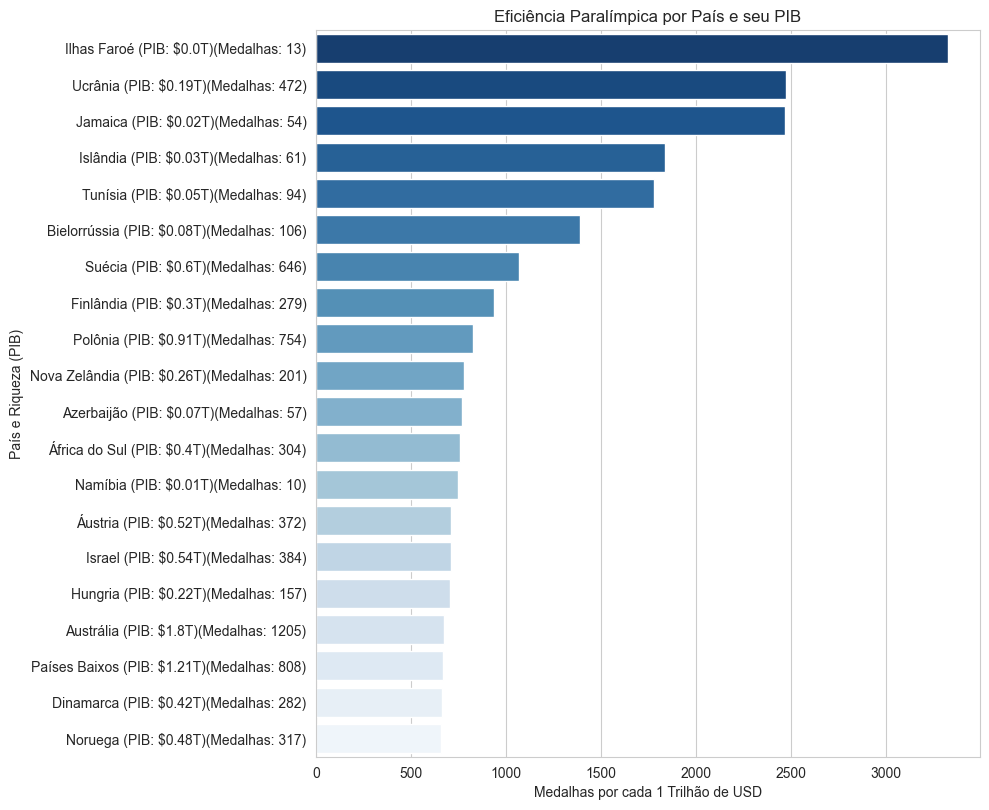

In [70]:
df_ranking = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Para')
df_ranking['Pais_com_PIB'] = df_ranking['País'] + " (PIB: $" + (df_ranking['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking['Total_Paralimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_ranking, 
    x='Eficiencia_Para', 
    y='Pais_com_PIB',
    hue='País', 
    palette='Blues_r', 
    legend=False
)

plt.tight_layout()

plt.title('Eficiência Paralímpica por País e seu PIB')
plt.xlabel('Medalhas por cada 1 Trilhão de USD')
plt.ylabel('País e Riqueza (PIB)')
plt.show()

Ao observar o gráfico, as Ilhas Faroé aparecem em primeiro lugar isolado. Isso ocorre devido a uma distorção estatística causada pelo PIB extremamente baixo, pois a fórmula de eficiência vai dividir o número de medalhas pelo PIB, quando o denominador (PIB) é um valor muito próximo de zero, o resultado da divisão tende ao infinito e a escala nominal. As Ilhas Faroé tem apenas 13 medalhas, mas como seu PIB é minúsculo ($0.0T$ no gráfico), elas parecem ser "infinitamente" mais eficientes que potências.

Para uma análise mais realista, vamos aplicar um filtro de PIB mínimo, evitando que economias muito pequenas distorçam o ranking de eficiência produtiva.

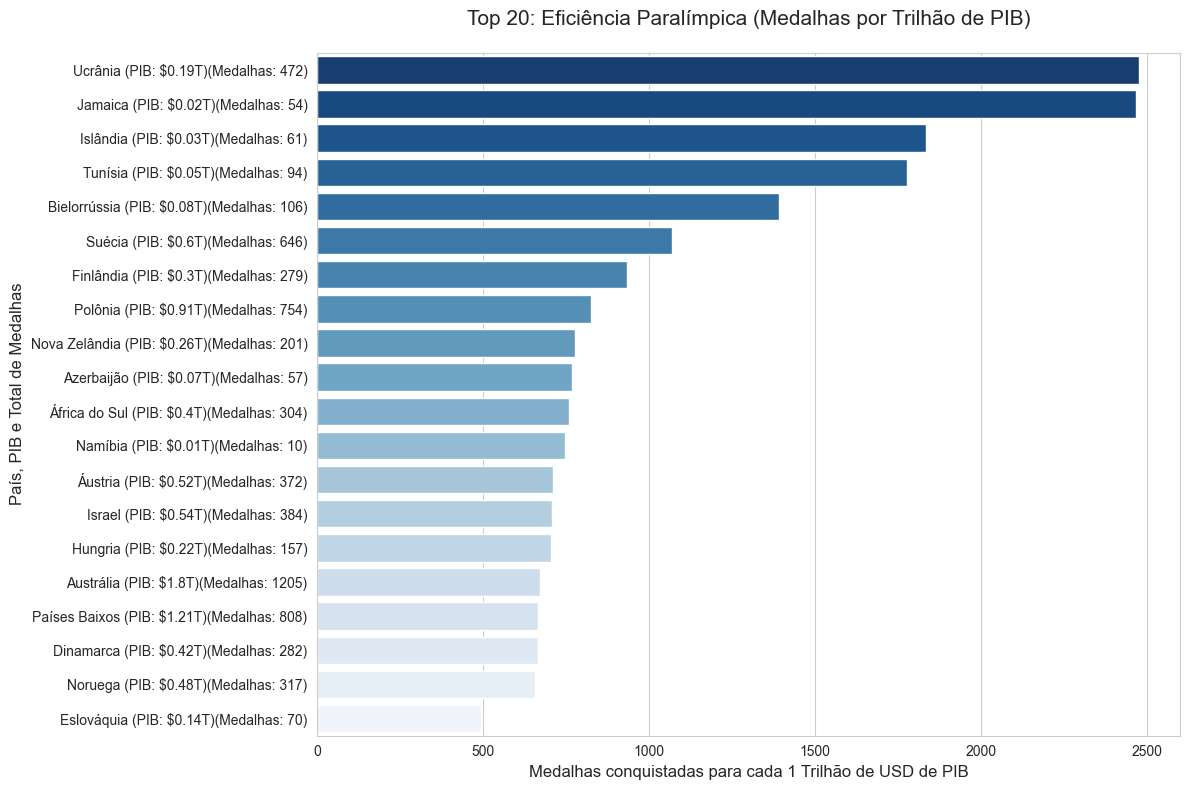

In [73]:
#filtro para 5 Bilhões (5e9) 
df_analise_socioeconomica = df_analise_socioeconomica[df_analise_socioeconomica['PIB_Numerico'] > 5e9]

df_ranking_filtrado = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Para')

df_ranking_filtrado['Pais_com_PIB'] = df_ranking_filtrado['País'] + " (PIB: $" + (df_ranking_filtrado['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking_filtrado['Total_Paralimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(12, 8))

grafico = sns.barplot(
    data=df_ranking_filtrado, 
    x='Eficiencia_Para', 
    y='Pais_com_PIB',
    hue='País', 
    palette='Blues_r',
    legend=False 
)

plt.title('Top 20: Eficiência Paralímpica (Medalhas por Trilhão de PIB)', fontsize=15, pad=20)
plt.xlabel('Medalhas conquistadas para cada 1 Trilhão de USD de PIB', fontsize=12)
plt.ylabel('País, PIB e Total de Medalhas', fontsize=12)


plt.tight_layout()

plt.show()

##### Olimpíadas

Aqui faremos o mesmo das Paralímpiadas

In [71]:
df_analise_socioeconomica['Eficiencia_Olimp'] = df_analise_socioeconomica['Total_Olimpico'] / (df_analise_socioeconomica['PIB_Numerico'] / 1e12) 

Sem filtro

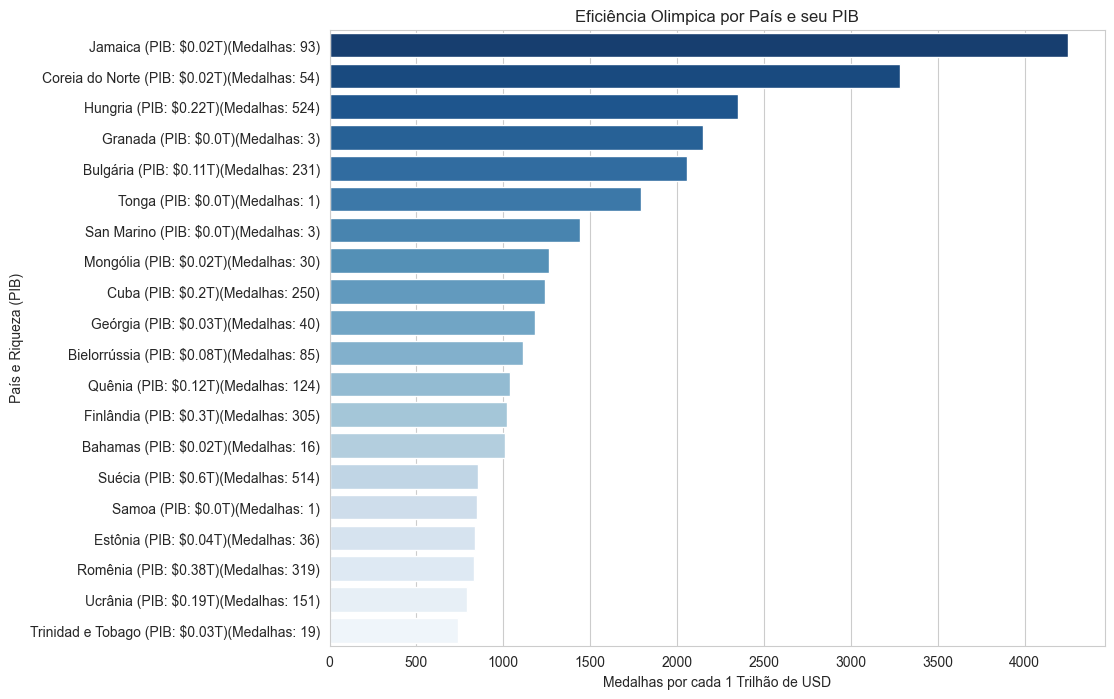

In [72]:
df_ranking = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Olimp')
df_ranking['Pais_com_PIB'] = df_ranking['País'] + " (PIB: $" + (df_ranking['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking['Total_Olimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_ranking, 
    x='Eficiencia_Olimp', 
    y='Pais_com_PIB',
    hue='País', 
    palette='Blues_r',
    legend=False
)

plt.title('Eficiência Olimpica por País e seu PIB')
plt.xlabel('Medalhas por cada 1 Trilhão de USD')
plt.ylabel('País e Riqueza (PIB)')
plt.show()

Com filtro

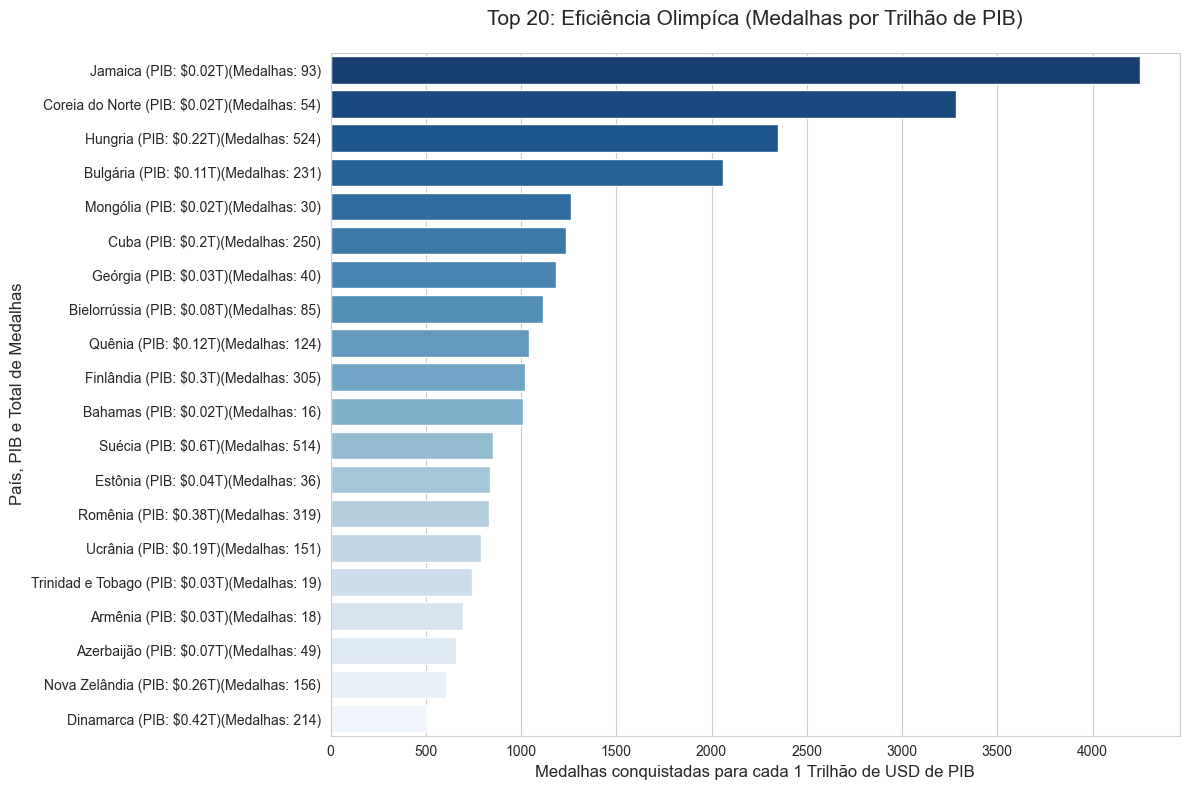

In [74]:
#filtro para 5 Bilhões (5e9) 
df_analise_socioeconomica = df_analise_socioeconomica[df_analise_socioeconomica['PIB_Numerico'] > 5e9]

df_ranking_filtrado = df_analise_socioeconomica.nlargest(20, 'Eficiencia_Olimp')

df_ranking_filtrado['Pais_com_PIB'] = df_ranking_filtrado['País'] + " (PIB: $" + (df_ranking_filtrado['PIB_Numerico'] / 1e12).round(2).astype(str) + "T)" + "(Medalhas: " + df_ranking_filtrado['Total_Olimpico'].astype(int).astype(str) + ")"

plt.figure(figsize=(12, 8))

grafico = sns.barplot(
    data=df_ranking_filtrado, 
    x='Eficiencia_Olimp', 
    y='Pais_com_PIB',
    hue='País', 
    palette='Blues_r',
    legend=False 
)

plt.title('Top 20: Eficiência Olimpíca (Medalhas por Trilhão de PIB)', fontsize=15, pad=20)
plt.xlabel('Medalhas conquistadas para cada 1 Trilhão de USD de PIB', fontsize=12)
plt.ylabel('País, PIB e Total de Medalhas', fontsize=12)


plt.tight_layout()

plt.show()

Aqui temos os gráficos iguais

#### Agrupamento

**Será que o PIB é mesmo um fator que dita o sucesso olímpico, ou existem países com economias menores que se comportam exatamente como potências esportivas?**

Para tentar responder a pergunta vamos usar o algoritmo K-Means para segmentar os países em três perfis (Desenvolvidos, Emergentes e Subdesenvolvidos) baseados no cruzamento entre riqueza (PIB) e sucesso esportivo.

##### Paralímpiadas

Para esta visualização, aplicamos a transformação de Escala Logarítmica ($log_{10}$) nos eixos de PIB e Medalhas pois a diferença entre o PIB dos países é gigantesca, enquanto algumas nações têm PIBs na casa dos Bilhões ($10^9$), outras chegam aos Trilhões ($10^{12}$).Em uma escala comum, os países pequenos ficariam "esmagados" no canto do gráfico. Aleém disso tem que haver um equilíbrio para o K-Means pois ele calcula a "distância" matemática entre os pontos para formar os grupos. Se usássemos os valores brutos, a diferença de trilhões no PIB ofuscaria a diferença de dezenas nas medalhas.

Com o uso do log, as distâncias ficam equilibradase nos permite identificar a Eficiência Real. Países que estão localizados na parte "mais alta" do gráfico, mesmo estando à esquerda (menos PIB), são as nações que superam as expectativas econômicas e entregam um desempenho paralímpico excepcional.

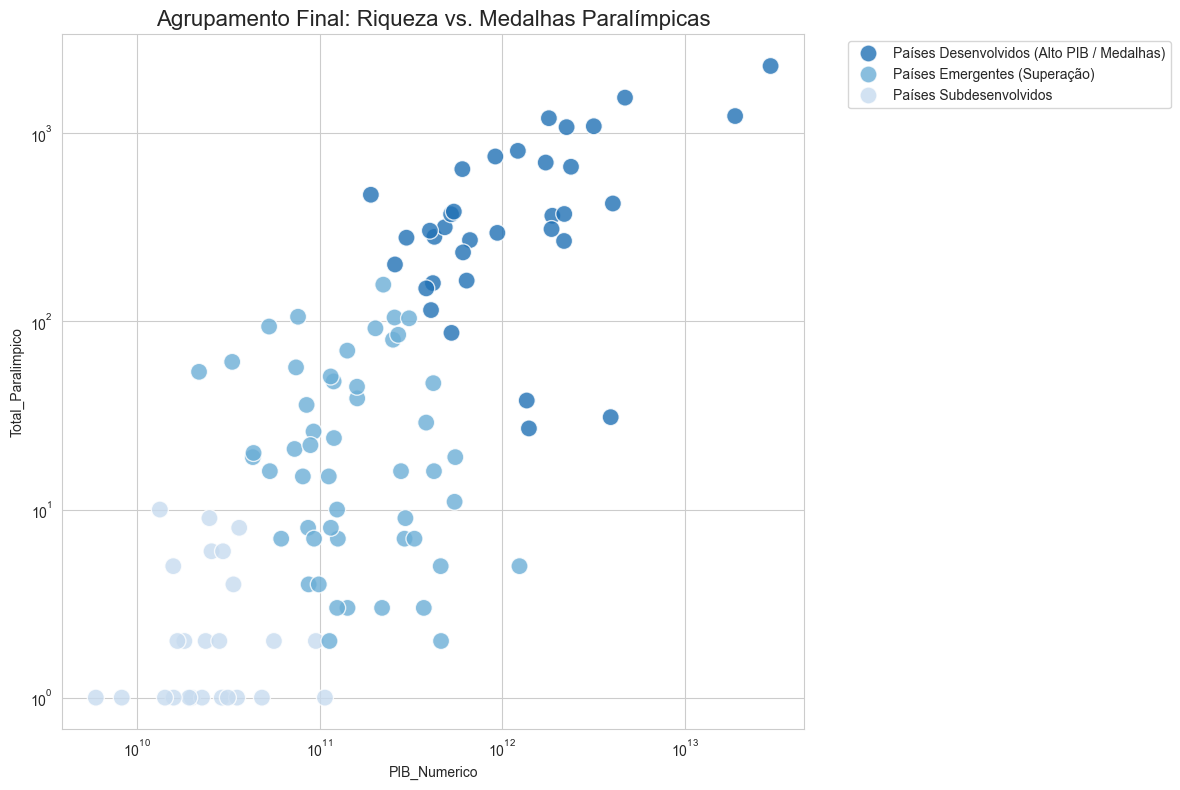

In [ ]:
df_final = df_analise_socioeconomica.dropna(subset=['PIB_Numerico', 'Total_Paralimpico', 'Total_Olimpico']).copy()

X = np.log10(df_final[['PIB_Numerico', 'Total_Paralimpico']] + 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = df_final.groupby('Cluster')['Total_Paralimpico'].mean().sort_values(ascending=False)

mapeamento = {
    cluster_means.index[0]: "Países Desenvolvidos (Alto PIB / Medalhas)",
    cluster_means.index[1]: "Países Emergentes (Superação)",
    cluster_means.index[2]: "Países Subdesenvolvidos",
}
df_final['Perfil_Cluster'] = df_final['Cluster'].map(mapeamento)

# 4. O GRÁFICO
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final, 
    x='PIB_Numerico', 
    y='Total_Paralimpico', 
    hue='Perfil_Cluster',
    palette='Blues_r', 
    s=150, alpha=0.8, edgecolor='w'
)

plt.xscale('log')
plt.yscale('log')
plt.title('Agrupamento Final: Riqueza vs. Medalhas Paralímpicas', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

A diagonal que é formada pelos pontos mostra que existe sim uma correlação entre PIB e Medalhas, mas a dispersão vertical dentro dos grupos prova que a economia não é o único fator que leva a isso.

##### Olimpíadas

Basicamente mesmo processo que as paralimpíadas

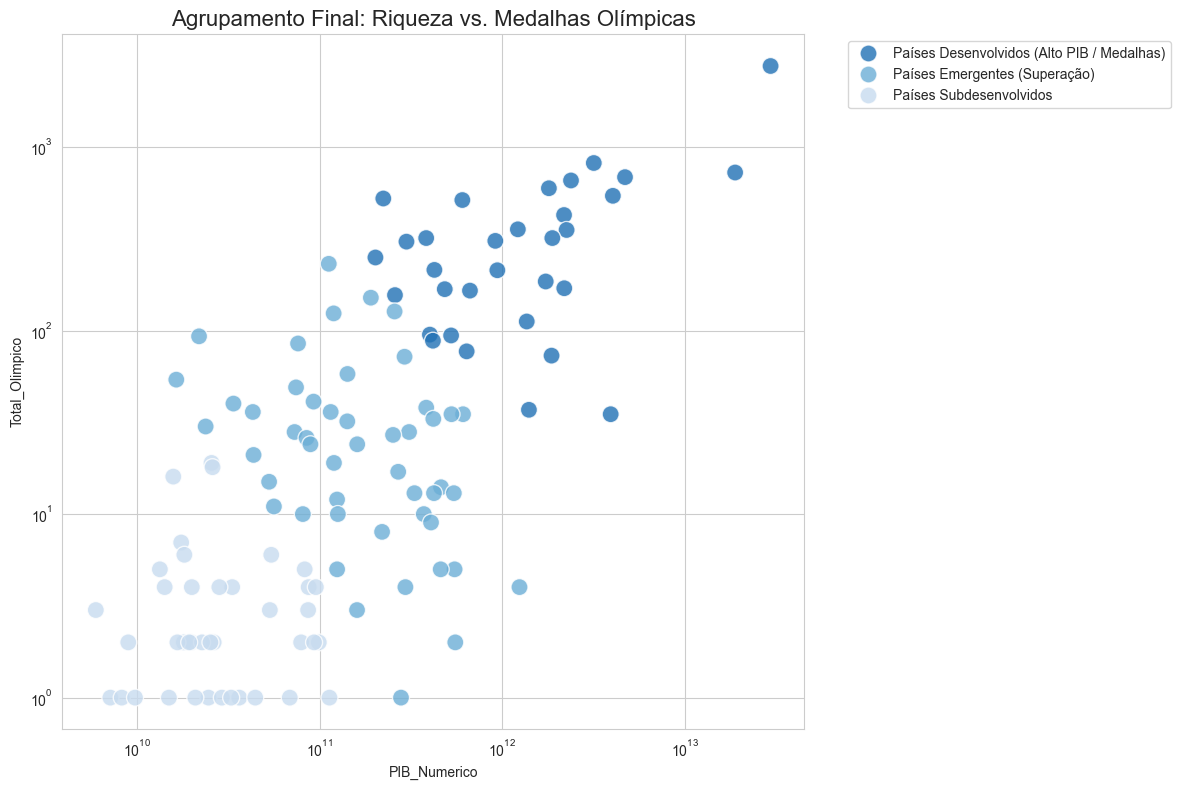

In [80]:
df_final = df_analise_socioeconomica.dropna(subset=['PIB_Numerico', 'Total_Paralimpico', 'Total_Olimpico']).copy()

X = np.log10(df_final[['PIB_Numerico', 'Total_Olimpico']] + 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = df_final.groupby('Cluster')['Total_Olimpico'].mean().sort_values(ascending=False)

mapeamento = {
    cluster_means.index[0]: "Países Desenvolvidos (Alto PIB / Medalhas)",
    cluster_means.index[1]: "Países Emergentes (Superação)",
    cluster_means.index[2]: "Países Subdesenvolvidos",
}
df_final['Perfil_Cluster'] = df_final['Cluster'].map(mapeamento)

# 4. O GRÁFICO
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_final, 
    x='PIB_Numerico', 
    y='Total_Olimpico', 
    hue='Perfil_Cluster',
    palette='Blues_r', 
    s=150, alpha=0.8, edgecolor='w'
)

plt.xscale('log')
plt.yscale('log')
plt.title('Agrupamento Final: Riqueza vs. Medalhas Olímpicas', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Analizando os dois gráficos podemos perceber que nas Paralimpíadas, países com PIB semelhante apresentam resultados muito variados, indicando maior influência de fatores não econômicos no desempenho. Já nas Olimpíadas, há uma relação mais direta entre riqueza e medalhas, tornando o sucesso mais dependente do PIB. Além disso, países emergentes se destacam mais nas Paralimpíadas, onde conseguem superar limitações econômicas com maior frequência.

### 5 - Pergunta 5

#### A "Correlação de Potência" (O Espelho Distorcido)
​A Pergunta: Os países que dominam as Olimpíadas são os mesmos que dominam as Paralimpíadas?
​O que esperar: Geralmente sim (EUA, China), mas existem outliers fascinantes.
​Exemplo: A Ucrânia e o Brasil costumam ter desempenhos proporcionalmente muito melhores nas Paralimpíadas do que nas Olimpíadas. O Reino Unido também investe pesadamente no paralímpico.
​A Análise: Um gráfico de dispersão (Scatter Plot) onde o eixo X são medalhas Olímpicas e o eixo Y são medalhas Paralímpicas. Quem estiver fora da linha diagonal é um caso curioso. 
​A Comparação: Criar um gráfico de dispersão (Scatter Plot). Eixo X: Total de Medalhas Olímpicas; Eixo Y: Total de Medalhas Paralímpicas.
​O que procurar: Países fora da curva. A China, por exemplo, tem uma dominância absoluta nas Paralimpíadas muito maior do que nas Olimpíadas. Por quê?


### Conclusão:

// Resumir os resultados encontrados e explicar por que são importantes. Apontar limitações, trabalhos futuros e melhorias que podem ser feitas.

OBS: Pelo menos três tipos diferentes de gráficos devem ser usados no relatório.